In [21]:
# Section B

# Q7: Detailed EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

In [22]:
# Load dataset
# Reading the dataset into a pandas DataFrame
data = pd.read_csv('train_Feb2025.csv')

In [23]:
# Display basic information about the dataset (column names, non-null values, data types)
display(data.info())
display(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

None

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [24]:
# Check for missing values in the dataset
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0]
display(missing_values)  # Display only columns with missing values

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


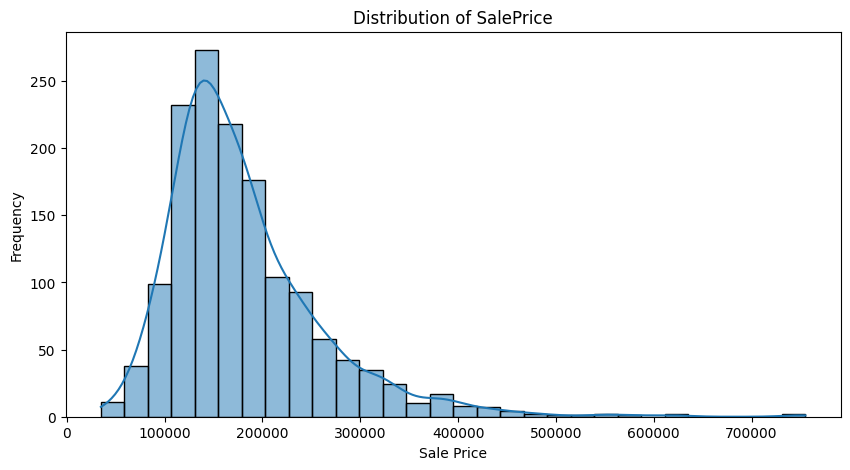

In [25]:
# Visualizing the target variable 'SalePrice'
plt.figure(figsize=(10, 5))
sns.histplot(data['SalePrice'], kde=True, bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

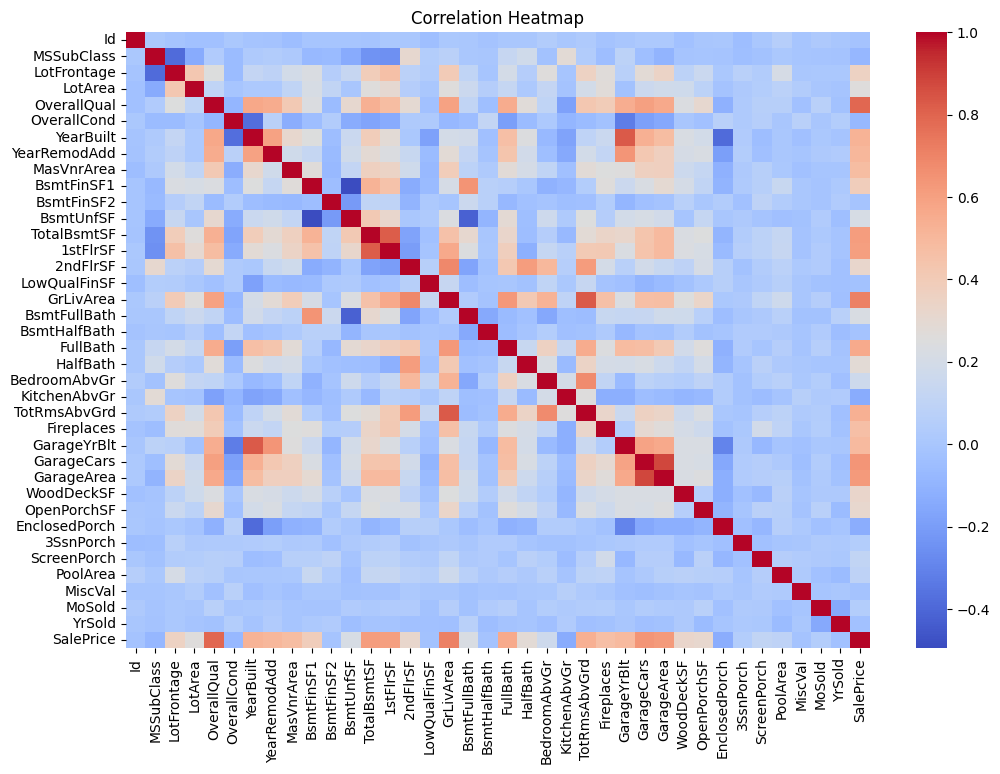

In [26]:
# Correlation heatmap to understand relationships between numerical variables
plt.figure(figsize=(12, 8))
numeric_data = data.select_dtypes(include=[np.number])  # Select only numerical columns
sns.heatmap(numeric_data.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [27]:
# Q8: Dummy Coding for Categorical Variables

# Identifying categorical columns for encoding
categorical_cols = data.select_dtypes(include=['object']).columns

# Applying One-Hot Encoding to categorical variables
dummy_data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

display(dummy_data.head())  # Displaying the first few rows of the transformed dataset

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [28]:
# Q9: Outlier Detection and Treatment

# Using the IQR method to identify outliers

# Selecting only numerical columns for outlier detection
numeric_data = data.select_dtypes(include=[np.number])

Q1 = numeric_data.quantile(0.25)  # First quartile
Q3 = numeric_data.quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range

# Identifying outliers as values that fall outside 1.5*IQR range
outlier_mask = (numeric_data < (Q1 - 1.5 * IQR)) | (numeric_data > (Q3 + 1.5 * IQR))

# Marking outliers as NaN for handling later, but only in the numerical columns
data[outlier_mask] = np.nan

display(data.isnull().sum())  # Checking missing values after marking outliers

,0
Id,0
MSSubClass,103
MSZoning,0
LotFrontage,347
LotArea,69
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [29]:
# Q10: Missing Values Treatment

# Filling missing values based on data type
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)  # Filling categorical variables with mode (most frequent value)
    else:
        data[col].fillna(data[col].median(), inplace=True)  # Filling numerical variables with median

display(data.isnull().sum())  # Ensuring no missing values remain

<ipython-input-29-427775336260>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)  # Filling numerical variables with median
<ipython-input-29-427775336260>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'd

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [30]:
# Q11: Scaling or Normalization

# Standardizing numerical features using StandardScaler
scaler = StandardScaler()
numeric_cols = data.select_dtypes(include=[np.number]).columns  # Selecting numerical columns
scaled_data = scaler.fit_transform(data[numeric_cols])
data[numeric_cols] = scaled_data  # Updating dataset with scaled values

display(data.head())  # Display first few rows after scaling

# Save processed dataset to a new CSV file
data.to_csv("processed_train_Feb2025.csv", index=False)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,-1.730865,0.412653,RL,-0.272814,-0.263909,Pave,Grvl,Reg,Lvl,AllPub,...,0.0,Gd,MnPrv,Shed,0.0,-1.599111,0.138777,WD,Normal,0.667455
1,-1.728492,-1.008276,RL,0.759072,0.104780,Pave,Grvl,Reg,Lvl,AllPub,...,0.0,Gd,MnPrv,Shed,0.0,-0.489110,-0.614439,WD,Normal,0.201927
2,-1.726120,0.412653,RL,-0.066436,0.633769,Pave,Grvl,IR1,Lvl,AllPub,...,0.0,Gd,MnPrv,Shed,0.0,0.990891,0.138777,WD,Normal,0.926081
3,-1.723747,0.767886,RL,-0.616775,0.088750,Pave,Grvl,IR1,Lvl,AllPub,...,0.0,Gd,MnPrv,Shed,0.0,-1.599111,-1.367655,WD,Abnorml,-0.513607
4,-1.721374,0.412653,RL,1.034241,1.598773,Pave,Grvl,IR1,Lvl,AllPub,...,0.0,Gd,MnPrv,Shed,0.0,2.100892,0.138777,WD,Normal,1.382988
